In [12]:
!pip install -q ultralytics shapely pyyaml opencv-python-headless sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00


In [2]:
import os, random, yaml
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from shapely.geometry import Polygon, box as shapely_box
from shapely.validation import make_valid
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# If running on Google Colab, uncomment the two lines below:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
BASE = '/content/drive/MyDrive/BTP'   # ← root of your project

# Path to your trained sleeper segmentation weights
SLEEPER_WEIGHTS = (
    f'{BASE}/yolo_seg/'
    'yolov8n-seg_Sleeper_Rail_Seg_20260418_2046/weights/best.pt'

)

# Source crack dataset — 12MP images with YOLO-seg polygon labels
CRACK_DATASET = {
    'train': {
        'images': f'{BASE}/twinsense-v2/yolo-seg-crack/data/images/train',
        'labels': f'{BASE}/twinsense-v2/yolo-seg-crack/data/labels/train',
    },
    'val': {
        'images': f'{BASE}/twinsense-v2/yolo-seg-crack/data/images/val',
        'labels': f'{BASE}/twinsense-v2/yolo-seg-crack/data/labels/val',
    },
}



SPLITS = ['train', 'val']

# ── Sleeper detection parameters ──────────────────────────────────────────────
SLEEPER_CLASS_ID = 0       # class index for "sleeper" in your sleeper model
SLEEPER_IMGSZ    = 4096    # inference size (sleepers are large → 1024 is fine)
SLEEPER_CONF     = 0.80    # confidence threshold for sleeper detection
MASK_PAD         = 50      # pixels of padding around each sleeper bbox

# ── Tiling parameters ────────────────────────────────────────────────────────
TILE_SIZE      = 1024       # px — square tiles at native resolution
OVERLAP_RATIO  = 0.01      # 20 % overlap between adjacent tiles

# ── Filtering parameters ─────────────────────────────────────────────────────
MIN_CRACK_FRAC  = 0.10    # a crack polygon must have ≥5% of its area in the tile
MIN_CRACK_PX    = 15      # minimum crack pixel area inside a tile
HARD_NEG_RATIO  = 0    # fraction of crack-free tiles kept as hard negatives
JPEG_QUALITY    = 95

# Where the tiled dataset will be written
OUTPUT_ROOT = f'{BASE}/twinsense-v2/sleeper-crack-roi-{TILE_SIZE}-v2'

RANDOM_SEED = 42
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f'Device : {DEVICE}')
print(f'Tile   : {TILE_SIZE}×{TILE_SIZE}px at native resolution\n')

Device : cuda
Tile   : 1024×1024px at native resolution



In [5]:
def parse_crack_labels(label_path: Path, img_w: int, img_h: int) -> list:
    """
    Read a YOLO-seg label file and return a list of Shapely Polygons
    in absolute (pixel) coordinates.

    Each line format:  <class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
    Coordinates are normalised [0,1] relative to image size.
    """
    polys = []
    if not label_path.exists():
        return polys
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:          # need at least class + 3 x,y pairs
                continue
            coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
            coords[:, 0] *= img_w       # normalised → pixel x
            coords[:, 1] *= img_h       # normalised → pixel y
            poly = Polygon(coords)
            if not poly.is_valid:
                poly = make_valid(poly)
            if poly.area > 0:
                polys.append(poly)
    return polys

In [6]:
def tile_coords(total_len: int, tile: int, overlap: float) -> list[tuple[int, int]]:
    """
    Generate (start, end) pairs for 1-D tiling with overlap.
    Always includes a final window aligned to the right edge.
    """
    step   = max(1, int(tile * (1 - overlap)))
    starts = list(range(0, total_len - tile, step))
    if not starts or starts[-1] + tile < total_len:
        starts.append(total_len - tile)
    starts = [max(0, s) for s in starts]   # clamp if image < tile
    return [(s, min(s + tile, total_len)) for s in starts]

In [7]:
def crack_to_tile_yolo(crack_poly, tx1, ty1):
    tile_box = shapely_box(tx1, ty1, tx1 + TILE_SIZE, ty1 + TILE_SIZE)
    clipped  = crack_poly.intersection(tile_box)

    if clipped.is_empty:
        return None

    clipped = make_valid(clipped)

    if clipped.geom_type == 'MultiPolygon':
        clipped = max(clipped.geoms, key=lambda g: g.area)

    if clipped.geom_type != 'Polygon' or clipped.area < MIN_CRACK_PX:
        return None

    coords = np.array(clipped.exterior.coords[:-1])

    if len(coords) < 3:
        return None

    coords[:, 0] = (coords[:, 0] - tx1) / TILE_SIZE
    coords[:, 1] = (coords[:, 1] - ty1) / TILE_SIZE

    coords = coords.clip(0.0, 1.0)

    return [0] + coords.flatten().tolist()

In [8]:
def write_yolo_line(line: list) -> str:
    """Format a label line for writing to a .txt file."""
    return ' '.join(str(v) if i == 0 else f'{v:.6f}'
                    for i, v in enumerate(line))

In [9]:
sleeper_model = YOLO(SLEEPER_WEIGHTS)
print('✅ Sleeper model loaded\n')

✅ Sleeper model loaded



In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║ VISUALIZE SLEEPER MODEL PREDICTIONS ON SAMPLE IMAGE       ║
# ╚══════════════════════════════════════════════════════════╝

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import shapely

# Specify the image name to visualize (or leave empty to use first available)
IMAGE_NAME = 'image_105'  # ← Change this to visualize different images

# ── Locate image ────────────────────────────────────────────────────────────
img_dir     = Path(CRACK_DATASET['train']['images'])
image_paths = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))

target_img = next((p for p in image_paths if IMAGE_NAME in p.stem), None)
if target_img is None:
    print(f"⚠️  Image '{IMAGE_NAME}' not found. Using first available image.")
    target_img = image_paths[0]

print(f"\n📷 Visualizing sleeper predictions on: {target_img.name}")
print(f"{'─' * 60}")

img_bgr   = cv2.imread(str(target_img))
H, W      = img_bgr.shape[:2]

# ── SAHI sliced inference (fixes duplicate detections on high-res images) ──
#    - slice_size  : must match SLEEPER_IMGSZ so model sees tiles at trained scale
#    - overlap     : 20% ensures sleepers at tile edges are captured once
#    - postprocess : NMM (Non-Maximum Merging) unions masks that overlap >50%
#      instead of simply dropping one, giving cleaner full-sleeper polygons
sahi_model = AutoDetectionModel.from_pretrained(
    model_type            = 'ultralytics',       # works for YOLOv8/v11 seg
    model_path            = str(sleeper_model.ckpt_path),
    confidence_threshold  = SLEEPER_CONF,
    device                = DEVICE,
)

sahi_result = get_sliced_prediction(
    str(target_img),
    sahi_model,
    slice_height          = SLEEPER_IMGSZ,
    slice_width           = SLEEPER_IMGSZ,
    overlap_height_ratio  = 0.2,
    overlap_width_ratio   = 0.2,
    postprocess_type      = 'NMM',               # merges masks across tile boundaries
    postprocess_match_threshold = 0.5,
    verbose               = 0,
)

# ── Filter to sleeper class only ────────────────────────────────────────────
sleeper_preds = [
    p for p in sahi_result.object_prediction_list
    if p.category.id == SLEEPER_CLASS_ID
]
sleeper_count = len(sleeper_preds)

print(f"Image dimensions  : {W}×{H}px")
print(f"Sleepers detected : {sleeper_count}")

# ── Print details ────────────────────────────────────────────────────────────
if sleeper_count > 0:
    print(f"\nSleeper details:")
    for idx, pred in enumerate(sleeper_preds):
        bbox = pred.bbox          # sahi BoundingBox
        bw   = int(bbox.maxx - bbox.minx)
        bh   = int(bbox.maxy - bbox.miny)
        area = bw * bh
        print(f"  [{idx + 1}] Area: {area:>8.0f}px² | "
              f"BBox: {bw}×{bh}px @ ({int(bbox.minx)}, {int(bbox.miny)}) | "
              f"Conf: {pred.score.value:.2f}")

# ── Visualization ────────────────────────────────────────────────────────────
vis = img_bgr.copy()

if sleeper_count > 0:
    # 1) Draw semi-transparent fills via overlay blend
    overlay = vis.copy()
    for pred in sleeper_preds:
        if pred.mask is None:
            continue
        # SAHI stores masks as bool arrays — convert to contours
        mask_bool = pred.mask.bool_mask          # H×W numpy bool array
        contours, _ = cv2.findContours(
            mask_bool.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
        cv2.fillPoly(overlay, contours, (0, 255, 0))

    cv2.addWeighted(overlay, 0.25, vis, 0.75, 0, vis)  # 25% green fill

    # 2) Draw outlines + labels on top (crisp, unaffected by blend)
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.6, W / 10000)               # scale label to image size
    thickness  = max(3,   W // 3000)

    for idx, pred in enumerate(sleeper_preds):
        # Outline
        if pred.mask is not None:
            mask_bool = pred.mask.bool_mask
            contours, _ = cv2.findContours(
                mask_bool.astype(np.uint8),
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE,
            )
            cv2.polylines(vis, contours, isClosed=True,
                          color=(0, 255, 0), thickness=thickness)

        # Label: index + confidence
        bbox  = pred.bbox
        cx    = int((bbox.minx + bbox.maxx) / 2)
        cy    = int((bbox.miny + bbox.maxy) / 2)
        label = f"#{idx+1}  {pred.score.value:.2f}"
        (tw, th), baseline = cv2.getTextSize(label, font, font_scale, 2)
        cv2.rectangle(vis,
                      (cx - tw//2 - 4, cy - th - baseline - 4),
                      (cx + tw//2 + 4, cy + baseline),
                      (0, 80, 0), -1)
        cv2.putText(vis, label,
                    (cx - tw//2, cy - baseline),
                    font, font_scale, (255, 255, 255), 2, cv2.LINE_AA)

# ── Display ──────────────────────────────────────────────────────────────────
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
dpi     = 150
fig_w   = min(20, W / dpi)
fig_h   = fig_w * H / W

plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
plt.imshow(vis_rgb)
plt.title(
    f'{target_img.name}  —  Sleeper Predictions  (Count: {sleeper_count})',
    fontsize=14, fontweight='bold'
)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete. ({sleeper_count} sleepers via SAHI sliced inference)")

In [19]:
stats = {
    split: {
        'images_processed': 0,
        'sleepers_found'  : 0,
        'tiles_total'     : 0,
        'tiles_positive'  : 0,
        'tiles_hard_neg'  : 0,
        'tiles_skipped'   : 0,
    }
    for split in SPLITS
}

In [20]:
for split in SPLITS:
    print(f'{"═" * 60}')
    print(f'  SPLIT: {split.upper()}')
    print(f'{"═" * 60}')

    img_dir  = Path(CRACK_DATASET[split]['images'])
    lbl_dir  = Path(CRACK_DATASET[split]['labels'])
    out_imgs = Path(OUTPUT_ROOT) / 'images' / split
    out_lbls = Path(OUTPUT_ROOT) / 'labels' / split
    out_imgs.mkdir(parents=True, exist_ok=True)
    out_lbls.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))
    print(f'  Source images: {len(image_paths)}\n')

    for img_path in image_paths:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        H, W = img_bgr.shape[:2]
        stats[split]['images_processed'] += 1

        # ── Step 1: Detect sleepers via SAHI sliced inference ────────────────
        #    Fixes duplicate detections caused by YOLO internally tiling the
        #    high-res image without proper cross-tile NMS.
        #    NMM merges masks that overlap >50% → one clean prediction per sleeper.
        sahi_result = get_sliced_prediction(
            str(img_path),
            sahi_model,
            slice_height                = SLEEPER_IMGSZ,
            slice_width                 = SLEEPER_IMGSZ,
            overlap_height_ratio        = 0.2,
            overlap_width_ratio         = 0.2,
            postprocess_type            = 'NMM',
            postprocess_match_threshold = 0.5,
            verbose                     = 0,
        )

        # Keep only the sleeper class
        sleeper_preds = [
            p for p in sahi_result.object_prediction_list
            if p.category.id == SLEEPER_CLASS_ID
        ]

        if not sleeper_preds:
            print(f'  [SKIP] No sleepers: {img_path.name}')
            continue

        # ── Step 2: Load crack labels (full-image pixel coords) ──────────────
        crack_polys = parse_crack_labels(lbl_dir / f'{img_path.stem}.txt', W, H)

        # ── Step 3: Per-sleeper → tile the crop ──────────────────────────────
        for s_idx, pred in enumerate(sleeper_preds):
            # SAHI BoundingBox gives floats in original image space — same
            # coordinate system as masks.xy was, so nothing else changes.
            bbox = pred.bbox
            sx1  = max(int(bbox.minx) - MASK_PAD, 0)
            sy1  = max(int(bbox.miny) - MASK_PAD, 0)
            sx2  = min(int(bbox.maxx) + MASK_PAD, W)
            sy2  = min(int(bbox.maxy) + MASK_PAD, H)
            scrop_w, scrop_h = sx2 - sx1, sy2 - sy1

            if scrop_w < TILE_SIZE // 2 or scrop_h < TILE_SIZE // 2:
                continue   # crop too small — skip

            stats[split]['sleepers_found'] += 1
            print(f'  {img_path.name} | sleeper {s_idx} | '
                  f'conf: {pred.score.value:.2f} | '
                  f'native crop: {scrop_w}×{scrop_h}px', end='')

            # Generate tile grid over the sleeper crop
            x_ranges = tile_coords(scrop_w, TILE_SIZE, OVERLAP_RATIO)
            y_ranges = tile_coords(scrop_h, TILE_SIZE, OVERLAP_RATIO)
            n_tiles  = len(x_ranges) * len(y_ranges)
            print(f' → {len(x_ranges)}×{len(y_ranges)} = {n_tiles} tiles')

            tile_pos = 0
            for (lx, rx) in x_ranges:
                for (ly, ry) in y_ranges:
                    stats[split]['tiles_total'] += 1

                    # Tile coords in ORIGINAL image space
                    tx1, ty1 = sx1 + lx, sy1 + ly
                    tx2, ty2 = sx1 + rx, sy1 + ry

                    # ── Check crack overlap ──────────────────────────────────
                    matched_lines = []
                    for cp in crack_polys:
                        if cp.area == 0:
                            continue
                        try:
                            tile_box = shapely_box(tx1, ty1, tx2, ty2)
                            inter    = cp.intersection(tile_box)
                        except Exception:
                            continue
                        if inter.area / cp.area < MIN_CRACK_FRAC:
                            continue
                        yolo_line = crack_to_tile_yolo(cp, tx1, ty1)
                        if yolo_line:
                            matched_lines.append(yolo_line)

                    has_crack = len(matched_lines) > 0

                    # ── Keep or skip ─────────────────────────────────────────
                    if not has_crack:
                        if random.random() > HARD_NEG_RATIO:
                            stats[split]['tiles_skipped'] += 1
                            tile_pos += 1
                            continue
                        stats[split]['tiles_hard_neg'] += 1
                    else:
                        stats[split]['tiles_positive'] += 1

                    # ── Save tile image at native resolution ─────────────────
                    stem     = f'{img_path.stem}_s{s_idx}_t{tile_pos:04d}'
                    tile_bgr = img_bgr[ty1:ty2, tx1:tx2]

                    # Pad edge tiles to exactly TILE_SIZE
                    if tile_bgr.shape[0] != TILE_SIZE or tile_bgr.shape[1] != TILE_SIZE:
                        pad_h = TILE_SIZE - tile_bgr.shape[0]
                        pad_w = TILE_SIZE - tile_bgr.shape[1]
                        tile_bgr = cv2.copyMakeBorder(
                            tile_bgr, 0, pad_h, 0, pad_w,
                            cv2.BORDER_CONSTANT, value=(0, 0, 0),
                        )

                    cv2.imwrite(
                        str(out_imgs / f'{stem}.jpg'), tile_bgr,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY],
                    )

                    # ── Save YOLO-seg label ──────────────────────────────────
                    lbl_path = out_lbls / f'{stem}.txt'
                    if matched_lines:
                        with open(lbl_path, 'w') as f:
                            f.write('\n'.join(
                                write_yolo_line(l) for l in matched_lines
                            ) + '\n')
                    else:
                        lbl_path.touch()   # hard negative → empty file

                    tile_pos += 1

    # ── Per-split summary ─────────────────────────────────────────────────────
    s    = stats[split]
    kept = s['tiles_positive'] + s['tiles_hard_neg']
    print(f'\n  ── {split.upper()} SUMMARY ──')
    print(f'  Source images      : {s["images_processed"]}')
    print(f'  Sleepers detected  : {s["sleepers_found"]}')
    print(f'  Total tiles        : {s["tiles_total"]}')
    print(f'  Positive tiles     : {s["tiles_positive"]:>5}  '
          f'({100 * s["tiles_positive"] / max(s["tiles_total"], 1):.1f}%)')
    print(f'  Hard-neg tiles     : {s["tiles_hard_neg"]:>5}  '
          f'({100 * s["tiles_hard_neg"] / max(s["tiles_total"], 1):.1f}%)')
    print(f'  Discarded tiles    : {s["tiles_skipped"]:>5}')
    print(f'  Final dataset size : {kept}\n')

════════════════════════════════════════════════════════════
  SPLIT: TRAIN
════════════════════════════════════════════════════════════
  Source images: 85

  image_103.jpg | sleeper 0 | conf: 0.95 | native crop: 8265×1439px → 9×2 = 18 tiles
  image_103.jpg | sleeper 1 | conf: 0.92 | native crop: 10833×1519px → 11×2 = 22 tiles
  image_103.jpg | sleeper 2 | conf: 0.91 | native crop: 6813×565px → 7×1 = 7 tiles
  image_105.jpg | sleeper 0 | conf: 0.96 | native crop: 9251×1371px → 10×2 = 20 tiles
  image_105.jpg | sleeper 1 | conf: 0.92 | native crop: 4305×1263px → 5×2 = 10 tiles
  image_105.jpg | sleeper 2 | conf: 0.91 | native crop: 11244×1749px → 12×2 = 24 tiles
  image_108.jpg | sleeper 0 | conf: 0.97 | native crop: 9379×1223px → 10×2 = 20 tiles
  image_108.jpg | sleeper 1 | conf: 0.95 | native crop: 11459×1615px → 12×2 = 24 tiles
  image_118.jpg | sleeper 0 | conf: 0.95 | native crop: 10931×1511px → 11×2 = 22 tiles
  image_118.jpg | sleeper 1 | conf: 0.93 | native crop: 8378×1482px →

In [21]:
data_yaml = {
    'path'  : OUTPUT_ROOT,
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 1,
    'names' : {0: 'crack'},
}

with open(Path(OUTPUT_ROOT) / 'data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f'✅ Tile dataset written to: {OUTPUT_ROOT}')
print(f'   data.yaml created — ready for training with Script 2.')

✅ Tile dataset written to: /content/drive/MyDrive/BTP/twinsense-v2/sleeper-crack-roi-1024-v2
   data.yaml created — ready for training with Script 2.


In [23]:
# ╔══════════════════════════════════════════════════════════╗
# ║ VISUALIZE GENERATED YOLO-SEG DATASET (TILES)             ║
# ╚══════════════════════════════════════════════════════════╝
# ───────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────
OUTPUT_ROOT = f'/content/drive/MyDrive/BTP/twinsense-v2/sleeper-crack-roi-{TILE_SIZE}-v2'

IMG_DIR = Path(OUTPUT_ROOT) / 'images/train'
LBL_DIR = Path(OUTPUT_ROOT) / 'labels/train'

NUM_SAMPLES = 2   # how many tiles to visualize

In [24]:
# ───────────────────────────────────────────────────────────
# HELPER: Read YOLO-seg label
# ───────────────────────────────────────────────────────────
def read_yolo_seg_label(label_path, img_w, img_h):
    """
    Returns list of polygons (pixel coords)
    """
    polygons = []

    if not label_path.exists():
        return polygons

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue

            coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2)

            # convert normalized → pixel
            coords[:, 0] *= img_w
            coords[:, 1] *= img_h

            polygons.append(coords.astype(int))

    return polygons


# ───────────────────────────────────────────────────────────
# DRAW FUNCTION
# ───────────────────────────────────────────────────────────
def draw_polygons(img, polygons):
    out = img.copy()

    for poly in polygons:
        cv2.polylines(out, [poly], isClosed=True, color=(0, 0, 255), thickness=2)

    return out

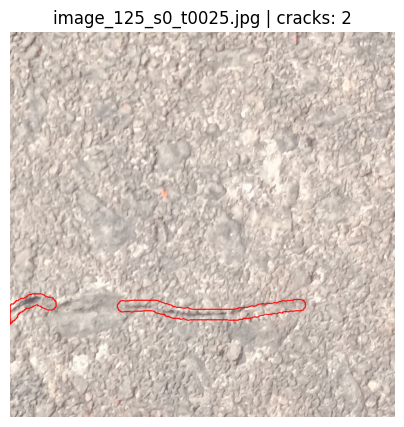

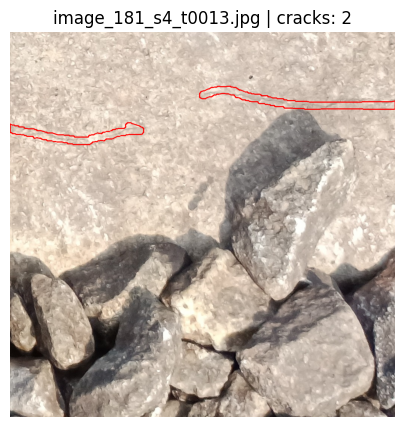

In [25]:
image_paths = list(IMG_DIR.glob('*.jpg'))
random.shuffle(image_paths)
image_paths = image_paths[:NUM_SAMPLES]

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        print(f'  [SKIP] Invalid image: {img_path.name}')
        continue

    h, w = img.shape[:2]

    label_path = LBL_DIR / f'{img_path.stem}.txt'

    polygons = read_yolo_seg_label(label_path, w, h)
    if not polygons:
        continue

    vis = draw_polygons(img, polygons)

    # convert BGR → RGB
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(vis_rgb)
    plt.title(f'{img_path.name} | cracks: {len(polygons)}')
    plt.axis('off')
    plt.show()